In [19]:
import pandas 
df_games = pandas.read_excel('data_fifa.xlsx', sheet_name='games')
df_tz = pandas.read_excel('data_fifa.xlsx', sheet_name='country_TZ')

In [20]:
def time_to_float(time_str):
    """Convert time string 'HH:MM' to float (e.g., '10:30' -> 10.5)"""
    hours, minutes = map(int, time_str.split(':'))
    return hours + minutes / 60

# Convert local_time to float
df_games["local_time"] = df_games["local_time"].apply(time_to_float)


In [23]:
df_games["team_1_localtime"] = 0
df_games["team_2_localtime"] = 0
for i in range(len(df_games)):
    try:
        tz_team_1 = df_tz[df_tz["Country"] == df_games["team_1"][i]]["UTC"].values[0]
        tz_team_2 = df_tz[df_tz["Country"] == df_games["team_2"][i]]["UTC"].values[0]
        df_games.at[i, "team_1_localtime"] = (df_games["local_time"][i] + tz_team_1 - df_games["UTC_Offset"][i])%24
        df_games.at[i, "team_2_localtime"] = (df_games["local_time"][i] + tz_team_2 - df_games["UTC_Offset"][i])%24
    except IndexError as e:
        print(f"IndexError at row {i}:")
        print(df_games.iloc[i])

/var/folders/fq/_ft8_sjj269gqq97gkttmwhr0000gn/T/ipykernel_30019/813940514.py:7: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_games.at[i, "team_1_localtime"] = (df_games["local_time"][i] + tz_team_1 - df_games["UTC_Offset"][i])%24
/var/folders/fq/_ft8_sjj269gqq97gkttmwhr0000gn/T/ipykernel_30019/813940514.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '4.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_games.at[i, "team_2_localtime"] = (df_games["local_time"][i] + tz_team_2 - df_games["UTC_Offset"][i])%24


In [28]:
# Create a dataframe where each row is (country, game)
df_country_game = pd.concat([
    df_games.assign(country=df_games['team_1'], localtime=df_games['team_1_localtime']),
    df_games.assign(country=df_games['team_2'], localtime=df_games['team_2_localtime'])
], ignore_index=True)

# Drop the original team columns and keep relevant columns
df_country_game = df_country_game.drop(columns=['team_1', 'team_2', 'team_1_localtime', 'team_2_localtime'])
df_country_game

,#match,group,date,local_time,stadium,city,country,day,UTC_Offset,localtime
0,25,A,2026-06-18,12.0,Mercedes-Benz Stadium,Atlanta,Czechia,2,-4,17.0
1,2,A,2026-06-11,22.0,Estadio Guadalajara,Guadalajara,Korea Republic,1,-6,13.0
2,52,C,2026-06-24,18.0,Mercedes-Benz Stadium,Atlanta,Morocco,3,-4,23.0
3,28,A,2026-06-18,21.0,Estadio Guadalajara,Guadalajara,Mexico,2,-6,21.0
4,13,H,2026-06-15,12.0,Mercedes-Benz Stadium,Atlanta,Spain,1,-4,17.0
...,...,...,...,...,...,...,...,...,...,...
139,3,B,2026-06-12,15.0,BMO Field,Toronto,Bosnia and Herzegovina,1,-4,20.0
140,34,E,2026-06-20,16.0,BMO Field,Toronto,Ivory Coast,2,-4,20.0
141,62,I,2026-06-26,15.0,BMO Field,Toronto,Iraq,3,-4,22.0
142,23,L,2026-06-17,19.0,BMO Field,Toronto,Panama,1,-4,18.0


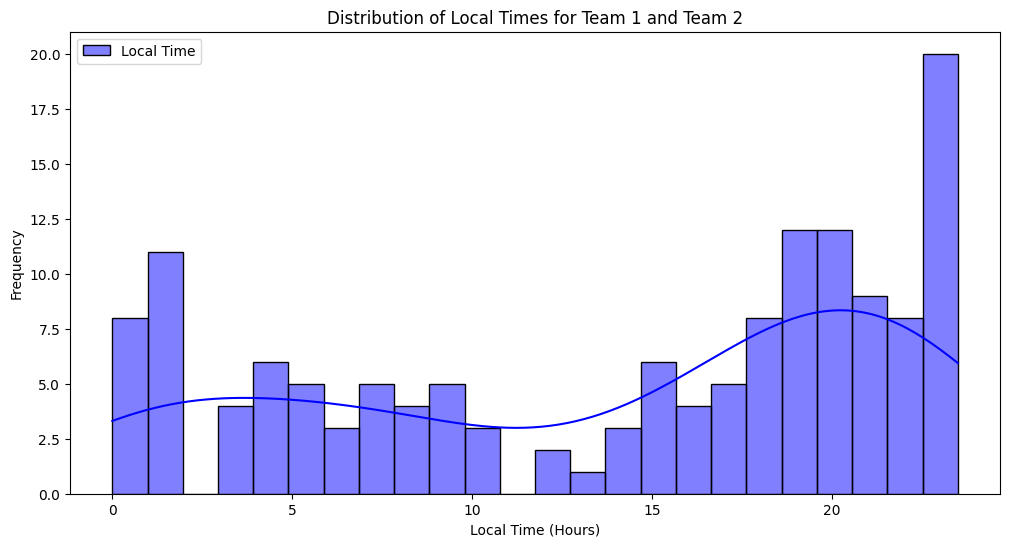

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
# Plotting the distribution of local times for team 1 and team 2
plt.figure(figsize=(12, 6))
data = pd.melt(df_country_game, value_vars=["localtime"], var_name='Team', value_name='Local Time')
sns.histplot(df_country_game["localtime"], bins=24, kde=True, color='blue', label='Local Time')
plt.xlabel('Local Time (Hours)')
plt.ylabel('Frequency')
plt.title('Distribution of Local Times for Team 1 and Team 2')
plt.legend()
plt.show()

In [31]:
with pandas.ExcelWriter('data_fifa.xlsx', engine='openpyxl', mode='a', if_sheet_exists='replace') as writer:
    df_country_game.to_excel(writer, sheet_name='country_game', index=False)